1. loading data
2. loading network
3. estimating patient-level molecular profiles

Setup

```bash
uv venv --python 3.11
source .venv/bin/activate

# Core dependencies (Napistu-Torch which bundles Napistu)
# Granular Torch installation for MPS compatibility
uv pip install torch==2.8.0
uv pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cpu.html
uv pip install 'napistu-torch[pyg,lightning]'
# Personal utilities package with genomics analysis functions
uv pip install "git+https://github.com/shackett/shackett-utils.git[statistics,genomics]" # stats extra for GAM support 
# Additional dependencies
uv pip install ipykernel openpyxl
python -m ipykernel install --user --name=forny-2023
```

In [1]:
import logging
import os
from types import SimpleNamespace

import pandas as pd
from IPython.display import display, HTML

from napistu.ontologies.constants import ONTOLOGIES

from shackett_utils.applications.forny_etl import forny_etl_and_normalize
from shackett_utils.genomics import adata_regression

# setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)
logging.getLogger('matplotlib.pyplot').setLevel(logging.WARNING) 

# File paths and data organization
# All input data should be placed in the SUPPLEMENTAL_DATA_DIR
# Cached results and models will be stored in CACHE_DIR

# paths
PROJECT_DIR = os.path.expanduser("~/Desktop/DATA/Forny2023")

# inputs
# network model to download from GCS and store in NAPISTU_DATA_DIR
NAPISTU_ASSET = "human_consensus_no_rxns"
NAPISTU_ASSET_VERSION = "20251218"
# edge prediction GNN to download from HuggingFace and store in NAPISTU_STORE_DIR
HF_EDGE_PREDICTOR_REPO = "seanhacks/relation_prediction"
HF_EDGE_PREDICTOR_REVISION = "main"

# processing settings f
REGRESSION_FORMULAS = {
    "transcriptomics" : "~ gender + s(date_freezing)",
    "proteomics" : "~ case + s(proteomics_runorder) + s(date_freezing)"
}
ANALYSIS_LAYER = "log2_centered"
MODALITY_SUMMARY_TYPES = ["augment"]

# derived paths
SUPPLEMENTAL_DATA_DIR = os.path.join(PROJECT_DIR, "input")
CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
NAPISTU_DATA_DIR = os.path.join(CACHE_DIR, ".napistu")
NAPISTU_STORE_DIR = os.path.join(CACHE_DIR, ".store")

# dataset metadata
FORNY_MODALITIES = SimpleNamespace(
    TRANSCRIPTOMICS = "transcriptomics",
    PROTEOMICS = "proteomics"
)

FORNY_DEFS = SimpleNamespace(
    INDICATOR_STR = 'is_{modality}'
)

MODALITIES = list(FORNY_MODALITIES.__dict__.values())

MODALITIES_ONTOLOGIES = {
    FORNY_MODALITIES.TRANSCRIPTOMICS : ONTOLOGIES.ENSEMBL_GENE,
    FORNY_MODALITIES.PROTEOMICS : ONTOLOGIES.UNIPROT
}

REGEXES_TO_MASKS = { x: FORNY_DEFS.INDICATOR_STR.format(modality = x) for x in MODALITIES }


In [2]:
from anndata import AnnData
from typing import Optional
from napistu.network.ng_core import NapistuGraph
from shackett_utils.statistics.hypothesis_testing import calculate_log_tstat_pvalue
from napistu.matching.species import features_to_pathway_species
from napistu.matching.mount import resolve_matches


def adata_to_long(adata: AnnData, layer: Optional[str] = None):
    """
    Convert an AnnData matrix to long-format DataFrame.
    
    Extract a matrix from the AnnData object and convert it to a long-format DataFrame.
    
    Parameters
    ----------
    adata : AnnData
        The AnnData object to convert.
    layer : Optional[str], default=None
        The layer to extract from the AnnData object. If None, the raw data matrix is used (X).

    Returns
    -------
    pd.DataFrame
        A 3-column DataFrame:
        - observation variable (set based on adata.obs.index.name)
        - feature variable (set based on adata.var.index.name)
        - "value" - the actual matrix data
    """
    
    matrix = adata.layers[layer] if layer else adata.X
    
    return (
        pd.DataFrame(
            matrix if not hasattr(matrix, "toarray") else matrix.toarray(),
            index=adata.obs_names,
            columns=adata.var_names
        )
        .stack()
        .rename_axis([adata.obs.index.name, adata.var.index.name])
        .reset_index(name="value")
    )

def calculate_personalized_t_statistics(
    adata: AnnData,
    layer: Optional[str] = "residuals",
    case_var: str = "case",
):
    """"
    Calculate patient-level t-statistics for each feature.

    Summarize each patient's measurements as t-statistics relative to the controls' mean and standard deviation.

    Parameters
    ----------
    adata : AnnData
        The AnnData object to calculate t-statistics for.
    layer : Optional[str], default="residuals"
        The layer to use for the t-statistics. If None, the raw data matrix is used (X).
    case_var : str, default="case"
        The column in adata.obs that indicates case/control status.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        A tuple of two DataFrames:
        - The first DataFrame contains the t-statistics for each patient and feature.
        - The second DataFrame contains the -log10 p-values for each patient and feature.

    """

    var_index_name =  adata.var.index.name
    obs_index_name =  adata.obs.index.name

    feature_abundances = (
        adata_to_long(adata, layer)
        .merge(adata.obs[[case_var]], left_on = obs_index_name, right_index = True)
    )

    # calculate the control's mean and sd for each feature
    control_summaries = (
        feature_abundances
        .query(f"{case_var} == 0")
        .groupby(var_index_name)["value"]
        .agg(["mean", "std"])
        .reset_index()
    )

    # count the number of controls - degrees of freedom on the t-statistic
    n_controls = len(feature_abundances.query(f"{case_var} == 0"))

    tall_z_scores = (
        feature_abundances
        .query(f"{case_var} == 1")
        # center disease values on the control's mean and scale by sd to calculate t-statistics
        .merge(control_summaries, left_on = var_index_name, right_on = var_index_name)
        .assign(z_score = lambda x: (x["value"] - x["mean"]) / x["std"])
        [[var_index_name, obs_index_name, "z_score"]]
    )

    patient_z_scores = tall_z_scores.pivot(index = obs_index_name, columns = var_index_name, values = "z_score").T

    patient_nlog10_pvalues = (
        tall_z_scores
        .assign(nlog10_pvalue = lambda x: -1 * calculate_log_tstat_pvalue(x["z_score"], n_controls))
        .pivot(index = obs_index_name, columns = var_index_name, values = "nlog10_pvalue").T
    )

    return patient_z_scores, patient_nlog10_pvalues


def add_feature_abundances_to_graph(
    feature_summaries: pd.DataFrame,
    species_identifiers: pd.DataFrame,
    napistu_graph: NapistuGraph,
    ontology: str,
    inplace: bool = True,
) -> NapistuGraph:
    """
    Map feature-level abundances to pathway species and add them as vertex attributes.

    Matches feature identifiers (e.g. Ensembl gene IDs) to pathway species via
    species_identifiers, resolves many-to-one and one-to-many degeneracy, then
    adds the resulting patient-level values as vertex attributes on the graph.

    Parameters
    ----------
    feature_summaries : pd.DataFrame
        Wide-format DataFrame with feature IDs as index and patient/sample IDs as
        columns. Values are per-feature abundances or statistics (e.g. -log10 p-values).
    species_identifiers : pd.DataFrame
        Mapping of pathway species to identifiers. Must have columns s_id, ontology,
        and identifier (or equivalent) for matching.
    napistu_graph : NapistuGraph
        The pathway graph to annotate with feature abundances.
    ontology : str
        Ontology name used for matching (e.g. "ensembl_gene", "uniprot").
        Must match a column in species_identifiers and the index/column naming
        in feature_summaries.
    inplace : bool, default=True
        If True, modify napistu_graph in place and return it.
        If False, copy the graph, add attributes to the copy, and return the copy.

    Returns
    -------
    NapistuGraph
        The graph with feature abundances added as vertex attributes.
        When inplace=True, returns the same object; when inplace=False, returns a copy.
    """
    graph = napistu_graph if inplace else napistu_graph.copy()

    matched = features_to_pathway_species(
        feature_identifiers=feature_summaries.reset_index(),
        species_identifiers=species_identifiers,  # has s_id, ontology, identifier columns
        ontologies={ontology},
        feature_identifiers_var=ontology,   # column in expr_long containing the IDs
        verbose=True,
    )

    # Resolve many-to-one (multiple genes → same s_id) and
    # one-to-many (gene → multiple s_ids) degeneracy
    species_data = resolve_matches(
        matched_data=matched,
        feature_id_var="feature_id",   # created automatically by features_to_pathway_species
        index_col="s_id",
        numeric_agg="weighted_mean",
        keep_id_col=False,             # drop the feature_id bookkeeping column
    )[feature_summaries.columns.tolist()]  # keep only patient columns

    graph._add_attributes_df(
        entity_data=species_data,
        target_entity="vertices",
    )

    return graph

In [3]:
# load the Forny data
mdata = forny_etl_and_normalize(SUPPLEMENTAL_DATA_DIR)

/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
# Process each modality
regression_results = list()
for modality in mdata.mod_names:
    
    modality_results = list()

    # Apply regression per feature
    summaries = adata_regression.adata_model_fitting(
        mdata[modality],
        REGRESSION_FORMULAS[modality],
        n_jobs=4,
        layer = ANALYSIS_LAYER,
        outputs = MODALITY_SUMMARY_TYPES,
        model_name = "fitting_covariates",
        progress_bar = False
    )

    # combine results and add modality first
    modality_results = {
        summary_type: summary.assign(modality = modality)[['modality'] + [col for col in summary.columns if col != 'modality']]
        for summary_type, summary in summaries.items()
    }
    
    # add results to the adata
    adata_regression.add_regression_results_to_anndata(
        mdata[modality],
        modality_results,
        inplace = True
    )
    
    regression_results.append(modality_results)

# fit each feature using modality-specific covariates to extract residuals for downstream analysis
regression_results_df = {
    summary_type: pd.concat([result[summary_type] for result in regression_results])
    for summary_type in MODALITY_SUMMARY_TYPES
}

assert all(regression_results_df["augment"].assign(dev = lambda x: x["y"] - (x[".fitted"] + x[".resid"]))["dev"].abs() < 1e-10)

# Calculate patient-level t-statistics for each modality
modality_statistics = dict()
modality_nlog10_pvalues = dict()
for modality in mdata.mod_names:
    modality_statistics[modality], 
    [modality] = calculate_personalized_t_statistics(mdata[modality])

INFO:shackett_utils.statistics.multi_model_fitting:Auto-detected model_class='gam' for formula='~ gender + s(date_freezing)'
INFO:shackett_utils.statistics.multi_model_fitting:Starting parallel model fitting with 4 cores...
INFO:shackett_utils.statistics.multi_model_fitting:Completed model fitting for 9134 features.
INFO:shackett_utils.statistics.multi_model_fitting:Auto-detected model_class='gam' for formula='~ case + s(proteomics_runorder) + s(date_freezing)'
INFO:shackett_utils.statistics.multi_model_fitting:Starting parallel model fitting with 4 cores...
INFO:shackett_utils.statistics.multi_model_fitting:Completed model fitting for 4788 features.


### Look at patient-level scores for MMUT stratified by mutation status

In [5]:
def _get_mut_category(mdata):

    df = pd.concat([
        mdata["transcriptomics"].obs["mut_category"],
        mdata["proteomics"].obs["mut_category"],
    ], axis=1)
    df.columns = ["tx", "prot"]

    # Sanity check: where both defined, they should match
    assert (df.dropna().eval("tx == prot")).all(), "Conflicting mut_category values!"

    return df["tx"].fillna(df["prot"]).rename("mut_category")


In [6]:
GENE_ASSOCIATIONS = {
    "transcriptomics" : "ENSG00000146085",
    "proteomics" : "P22033"
}

mut_category = _get_mut_category(mdata)

# select MMUT protein and stratify by the "mut_status" phenotype (which is 1 for MMUT LOFs)
mmut_stats = (
    pd.concat({
        **{f"{modality}_z_score": stats.loc[GENE_ASSOCIATIONS[modality]] 
        for modality, stats in modality_statistics.items()},
        **{f"{modality}_nlog10_pvalue": stats.loc[GENE_ASSOCIATIONS[modality]] 
        for modality, stats in modality_nlog10_pvalues.items()},
    }, axis = 1)
    .join(mut_category)
)



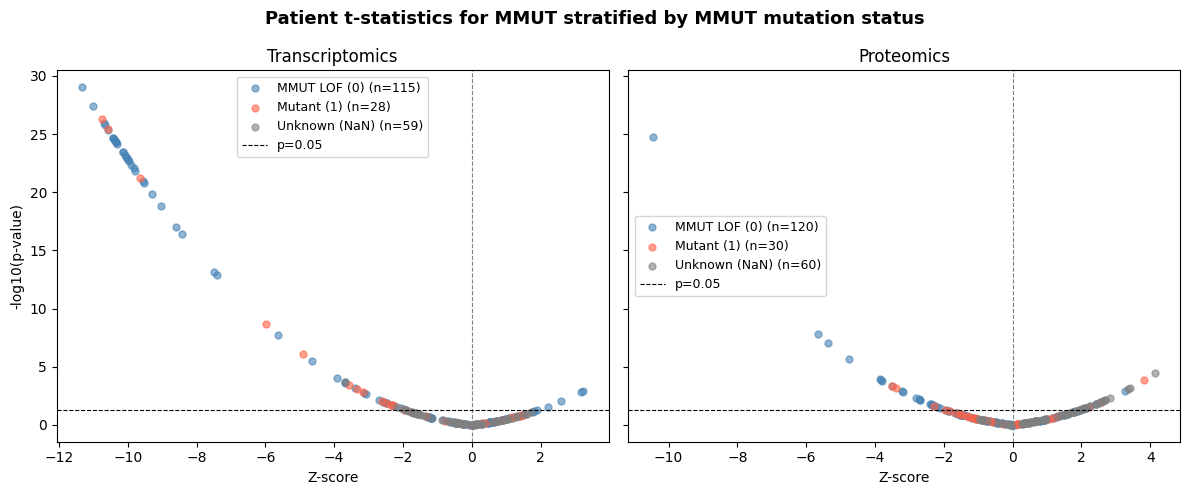

In [7]:
import matplotlib.pyplot as plt
import numpy as np

modalities = ["transcriptomics", "proteomics"]
category_style = {
   0.0: ("steelblue", "MMUT LOF (0)"),
   1.0: ("tomato", "Mutant (1)"),
   np.nan: ("gray", "Unknown (NaN)"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, mod in zip(axes, modalities):
   for cat_val, (color, label) in category_style.items():
      if isinstance(cat_val, float) and np.isnan(cat_val):
         mask = mmut_stats["mut_category"].isna()
      else:
         mask = mmut_stats["mut_category"] == cat_val

      df = mmut_stats[mask].dropna(subset=[f"{mod}_z_score", f"{mod}_nlog10_pvalue"])
      ax.scatter(df[f"{mod}_z_score"], df[f"{mod}_nlog10_pvalue"],
                  alpha=0.6, s=25, color=color, label=f"{label} (n={len(df)})")

   ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
   ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8, label="p=0.05")

   ax.set_xlabel("Z-score")
   ax.set_ylabel("-log10(p-value)" if mod == "transcriptomics" else "")
   ax.set_title(mod.capitalize())
   ax.legend(fontsize=9)

fig.suptitle("Patient t-statistics for MMUT stratified by MMUT mutation status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Load NapistuGraph

In [8]:
from napistu_torch.napistu_data_store import NapistuDataStore
from napistu.gcs.downloads import load_public_napistu_asset
from napistu.gcs.constants import GCS_SUBASSET_NAMES
from pathlib import Path

# Download raw data from GCS
napistu_artifact_paths = {
    subasset : load_public_napistu_asset(
        NAPISTU_ASSET,
        NAPISTU_DATA_DIR,
        subasset=subasset,
        version=NAPISTU_ASSET_VERSION
    ) for subasset in [GCS_SUBASSET_NAMES.SBML_DFS, GCS_SUBASSET_NAMES.NAPISTU_GRAPH, GCS_SUBASSET_NAMES.SPECIES_IDENTIFIERS]
}

# Load and convert to non-read-only in one step
store = NapistuDataStore.from_huggingface(
    repo_id=HF_EDGE_PREDICTOR_REPO,
    store_dir=Path(NAPISTU_STORE_DIR),
    revision=HF_EDGE_PREDICTOR_REVISION,
    sbml_dfs_path=napistu_artifact_paths[GCS_SUBASSET_NAMES.SBML_DFS],
    napistu_graph_path=napistu_artifact_paths[GCS_SUBASSET_NAMES.NAPISTU_GRAPH],
)


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:httpx:HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:✓ HuggingFace authentication verified
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/seanhacks/relation_prediction "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:Loading NapistuDataStore from seanhacks/relation_prediction (revision: main)...
INFO:napistu_torch.ml.hugging_face:Downloading registry.json...
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/seanhacks/relation_prediction/resolve/main/registry.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datase

## Update NapistuGraph with learned edge weights

In [9]:
from napistu_torch.evaluation.manager import RemoteEvaluationManager

# load an edge prediction model which contains a learned edge encoder
evaluation_manager = RemoteEvaluationManager.from_huggingface(
    "seanhacks/edge_prediction_mlp_256e",
    data_store_dir=".store",
)

# load the model and data
model = evaluation_manager.load_model_from_checkpoint()
napistu_data = evaluation_manager.load_napistu_data()

napistu_graph = store.load_napistu_graph()
napistu_data.validate_graph_alignment(napistu_graph)

# pull out learned edge weights (if an edge encoder is present)
if model.task.encoder.edge_weighting_type != "learned_encoder":
    raise ValueError("The provided model does not have a learned edge encoder.")
edge_encodings = model.get_learned_edge_weights(napistu_data)

# add learned edge weights to the NapistuData object (i.e., the PyG version of the NapistuGraph)
# larger scores are better supported; bounded on [0, 1]
napistu_graph.es["weight"] = edge_encodings.detach().cpu().numpy()
# flip all of the edges so they flow from effects to causes
napistu_graph.reverse_edges()


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/seanhacks/edge_prediction_mlp_256e "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/seanhacks/edge_prediction_mlp_256e/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/seanhacks/edge_prediction_mlp_256e/9ed12a9a7d13370a7664ddff2959b4e99813b110/config.json "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:Config available at: /Users/sean/.cache/huggingface/hub/models--seanhacks--edge_prediction_mlp_256e/snapshots/9ed12a9a7d13370a7664ddff2959b4e99813b110/config.json (using default cache)
INFO:napistu_torch.evaluation.manager:Loading existing data store from .store
INFO:httpx:HTTP Request: HEAD https://huggingface.co/seanhacks/edge_prediction_mlp_256e/resolve/main/model.ckpt "HTTP/1.1 302 Found"
INFO:napistu_torch.ml.hugging_face:Checkpoint available at: /Users/sean/.cache/huggingface/hub/models--seanhacks--edge_pre

In [ ]:
species_identifiers = pd.read_csv(napistu_artifact_paths[GCS_SUBASSET_NAMES.SPECIES_IDENTIFIERS], sep="\t")

modality_attr_metadata = list()
for modality_name, modality_data in modality_nlog10_pvalues.items():

    modality_data_working = modality_data.copy()
    ontology = MODALITIES_ONTOLOGIES[modality_name]

    # update patient attributes with a modality precursor
    attr_names = [f"{modality_name}_{col}" for col in modality_data.columns]
    modality_data_working.columns = attr_names

    # map from attributes to a modality indicator used for null distribution construction
    modality_mask_attr = FORNY_DEFS.INDICATOR_STR.format(modality = modality_name)
    modality_data_working[modality_mask_attr] = 1 # add the modality indicator as a column so its added to the graph
    
    modality_attr_metadata.append(pd.DataFrame({
        "modality" : modality_name,
        "attribute" : attr_names,
        "mask" : modality_mask_attr
    }))

    add_feature_abundances_to_graph(
        modality_data_working,
        species_identifiers,
        napistu_graph,
        ontology,
        inplace = True
    )

attr_metadata = pd.concat(modality_attr_metadata)


In [11]:
PPR_NULL_TMP_PATH = os.path.join(CACHE_DIR, "ppr_nulls.csv")
from napistu.network.net_propagation import network_propagation_with_null


In [34]:
N_NULL_SAMPLES = 1000
OVERWRITE = False

# split up by mask type (here, just transcriptomics vs proteomics)
# and calculate PPR enrichment with a pooled null distribution for each mask
mask_to_measures = attr_metadata.groupby('mask')['attribute'].apply(list).to_dict()

if os.path.isfile(PPR_NULL_TMP_PATH) and not OVERWRITE:
    logger.info(f"Loading PPR nulls from cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls = pd.read_csv(PPR_NULL_TMP_PATH, sep="\t", index_col=0)
else:
    logger.info(f"Calibrating PPR enrichments by permuting vertex attributes among masked vertices")
    ppr_results = list()

    for mask_key, mask_attrs in mask_to_measures.items():
        logger.info(f"Calculating PPR enrichments for {mask_key}")

        modality_ppr_with_nulls = network_propagation_with_null(
            napistu_graph,
            attributes = mask_attrs,
            mask = {attr : mask_key for attr in mask_attrs},
            propagation_method = "personalized_pagerank",
            additional_propagation_args = { "damping": 0.85 },
            null_strategy = "pooled_vertex_permutation",
            n_samples = N_NULL_SAMPLES,
            verbose = True    
        )   

        ppr_results.append(modality_ppr_with_nulls)

    ppr_with_nulls = pd.concat(ppr_results, axis = 1)

    logger.info(f"Saving PPR nulls to cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls.to_csv(PPR_NULL_TMP_PATH, sep="\t")

INFO:__main__:Loading PPR nulls from cache at /Users/sean/Desktop/DATA/Forny2023/cache/ppr_nulls.csv


In [54]:
from shackett_utils.statistics.hypothesis_testing import quantile_to_pvalue
from shackett_utils.statistics.multi_model_fitting import control_fdr

def floor_pvalue_by_resolution(p_value, n_samples):
    """
    Floor p-values by resolution.
    """
    
    return (p_value + 1 / n_samples) * (n_samples / (n_samples + 1))


def plot_ppr_enrichment_histograms(fdr_controlled_results):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    fdr_controlled_results[fdr_controlled_results["is_enriched"] == False]["p_value"].hist(
        bins=50, ax=axes[0]
    )
    axes[0].set_title("Depleted (False)")
    axes[0].set_xlabel("P-value")
    axes[0].set_ylabel("Count")

    fdr_controlled_results[fdr_controlled_results["is_enriched"] == True]["p_value"].hist(
        bins=50, ax=axes[1]
    )
    axes[1].set_title("Enriched (True)")
    axes[1].set_xlabel("P-value")

    plt.tight_layout()
    plt.show()


In [ ]:
# name index to vertex_id
tall_ppr_enrichments = (
    ppr_with_nulls
    .reset_index()
    .rename(columns={"index": "vertex_name"})
    .melt(id_vars=["vertex_name"], var_name="attribute", value_name="ppr_null_quantile")
    # drop missing values (due to presence in one but not both modalities)
    .dropna(subset = "ppr_null_quantile")
    # convert to 2-tailed p-values
    .assign(p_value = lambda x: quantile_to_pvalue(x["ppr_null_quantile"], "two-tailed"))
    .assign(is_enriched = lambda x: x["ppr_null_quantile"] > 0.5)
    # correct for 0 p-values by flooring based on the # of null samples
    .assign(p_value = lambda x: floor_pvalue_by_resolution(x["p_value"], N_NULL_SAMPLES))
    .assign(nulls_gt_observed = lambda x: ((1 - x["ppr_null_quantile"])*N_NULL_SAMPLES).fillna(-1).astype(int))
    .merge(attr_metadata[["modality", "attribute"]], on = "attribute")
)

fdr_controlled_results = control_fdr(
    tall_ppr_enrichments,
    grouping_vars = ["modality", "is_enriched"],
    require_groups = True
)


INFO:shackett_utils.statistics.multi_model_fitting:Applying FDR control within groups: modality, is_enriched


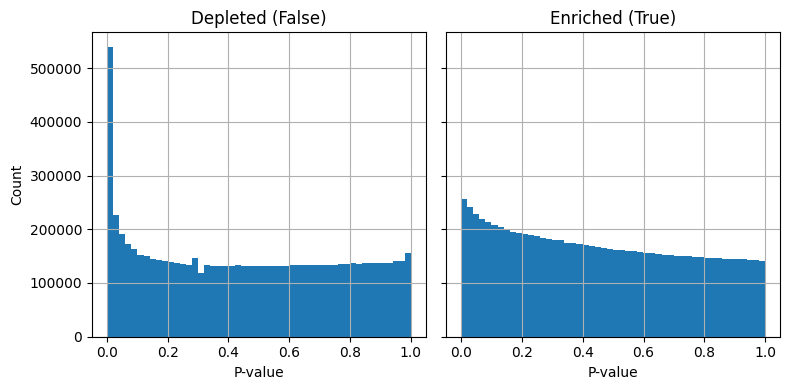

In [55]:
plot_ppr_enrichment_histograms(fdr_controlled_results)